<class 'pandas.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     str    
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  str    
 6   weather_description  48204 non-null  str    
 7   date_time            48204 non-null  str    
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), str(4)
memory usage: 5.0 MB
      holiday    temp  rain_1h  snow_1h  clouds_all  weather_main  \
48199     NaN  283.45      0.0      0.0          75        Clouds   
48200     NaN  282.76      0.0      0.0          90        Clouds   
48201     NaN  282.73      0.0      0.0          90  Thunderstorm   
48202     NaN  282.

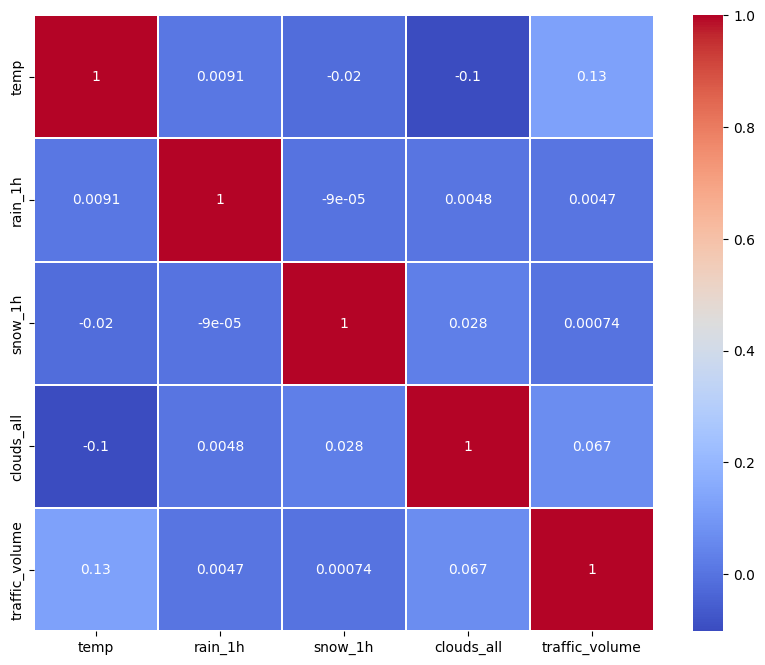

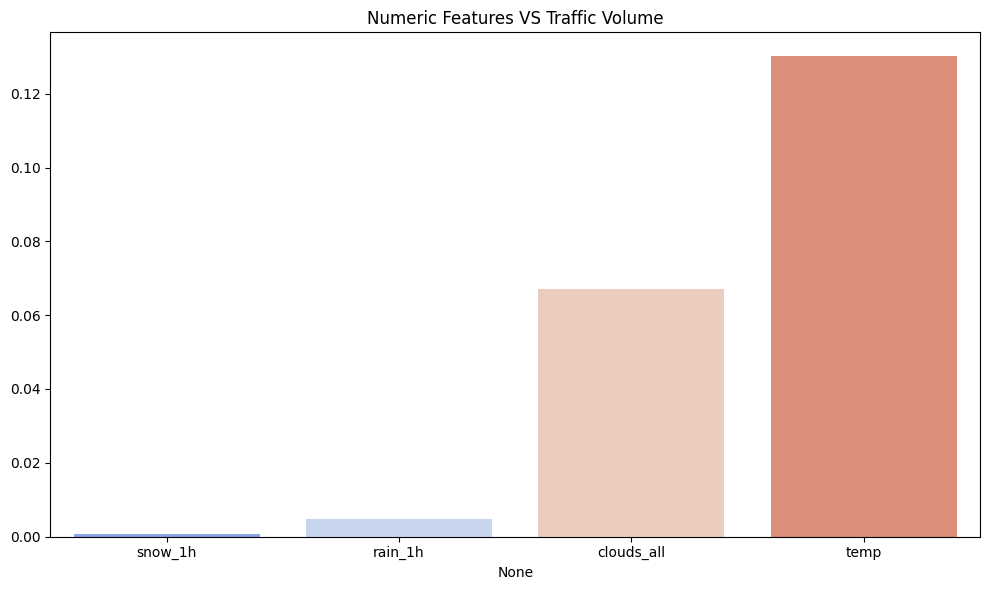

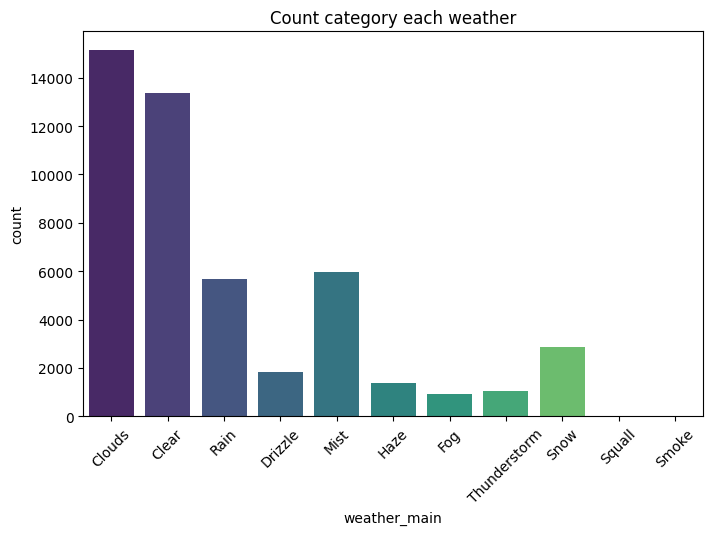

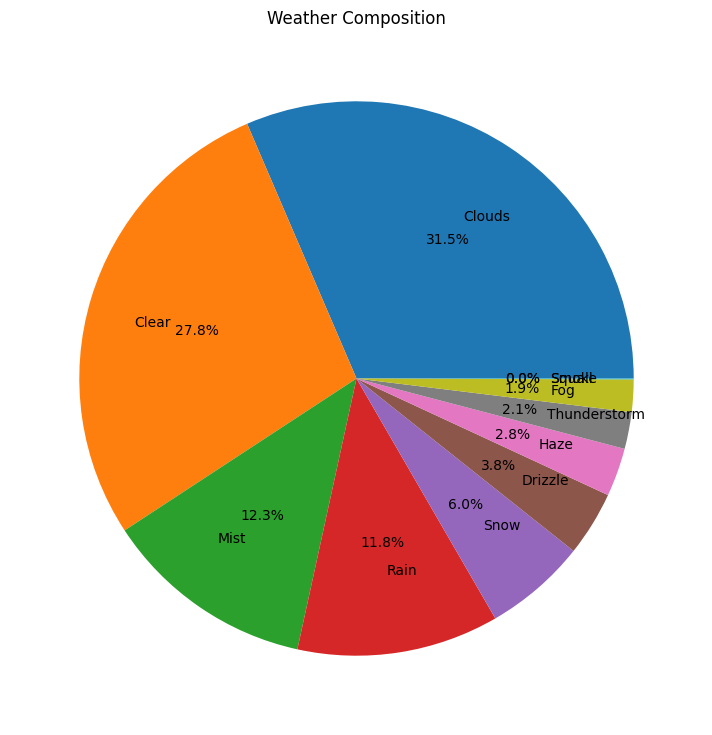

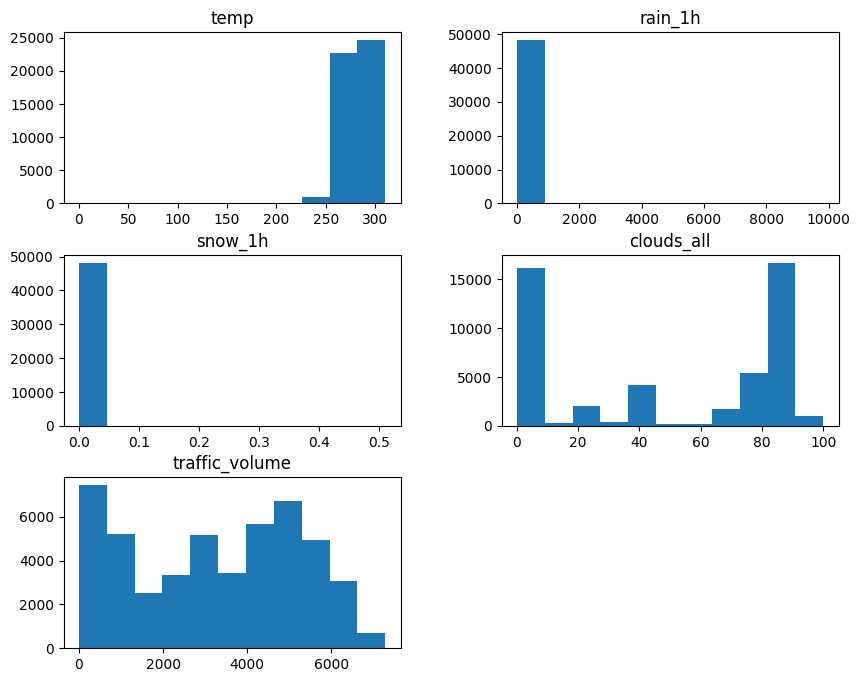

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Traffic_Volume.csv.gz')
df.info()
print(df.tail())
print(df.describe())

# Check duplicated
print('\nduplicated:')
print(df.duplicated().sum())
df = df.drop_duplicates()
print('\nafter duplicated:')
print(df.duplicated().sum())

# Check missing value
print('\nmissing value:')
print(df.isnull().sum())
missing = df['holiday'].count()/len(df['holiday'])
print(100-(missing*100),'%')

# Visualize correlation each features
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm', linewidths=0.01, annot=True)
plt.show()

df_numerik = df.select_dtypes(include="number")
korelasi_traffic = (
    df_numerik.corr()["traffic_volume"].drop("traffic_volume").sort_values()
)

plt.figure(figsize=(10, 6))
sns.barplot(x=korelasi_traffic.index, y=korelasi_traffic.values, palette="coolwarm")
plt.title("Numeric Features VS Traffic Volume")
plt.tight_layout()  
plt.show()

# Category each features
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="weather_main", palette="viridis", )
plt.title("Count category each weather")
plt.xticks(rotation=45)
plt.show()

# Weather composition
weather_counts = df['weather_main'].value_counts()
plt.figure(figsize=(13,9))
plt.pie(weather_counts.values, labels=weather_counts.index, autopct='%1.1f%%',labeldistance=0.7)
plt.title('Weather Composition')
plt.show()

# Variance of numerical features
df.hist(bins=11, figsize=(10,8), grid=False)
plt.show()

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# Parse datetime and extract temporal features
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour']      = df['date_time'].dt.hour
df['day']       = df['date_time'].dt.day
df['month']     = df['date_time'].dt.month
df['weekday']   = df['date_time'].dt.weekday
df['is_weekend']= (df['weekday'] >= 5).astype(int)

# Sort by time 
df = df.sort_values('date_time').reset_index(drop=True)

df = df.drop(columns=['date_time', 'weather_description', 'holiday'])

# Split data
x = df.drop('traffic_volume', axis=1)
y = df['traffic_volume']

cat = x.select_dtypes(include=['object', 'category']).columns.tolist()
num = x.select_dtypes(include=['number']).columns.tolist()

# Sequential split (not shuffle)
split_idx       = int(len(x) * 0.8)
x_train, x_test = x.iloc[:split_idx], x.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Threshold based on training median only
THRESHOLD = y_train.median()

# Weather stats 
df_train = df.copy()
hourly_dist = (
    df_train.groupby(['month', 'hour'])[['temp', 'rain_1h', 'snow_1h', 'clouds_all']]
    .median()
    .reset_index()
)

# Preprocessing
preprocessing = ColumnTransformer(
    transformers=[
        ('Encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat),
        ('Scaler',  RobustScaler(), num),
    ],
    remainder='passthrough'
)

# Models
models = {
    'Hist Gradient Boosting': HistGradientBoostingRegressor(max_iter=200, random_state=42),
    'Random Forest':          RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Linear Model':           LinearRegression(),
}

# Pipeline
best_model = None
best_score = float('inf')

for name, method in models.items():
    main_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessing),
        ('model', method)
    ])
    main_pipeline.fit(x_train, y_train)
    predict = main_pipeline.predict(x_test)

    # Evaluate
    mae = mean_absolute_error(y_test, predict)
    r2  = r2_score(y_test, predict)

    print(f'\n{name}')
    print(f'  MAE  : {mae:.2f}')
    print(f'  R²   : {r2:.4f}')

    if mae < best_score:
        best_score = mae
        best_name  = name

# Refit best model
best_model = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('model', models[best_name])
])
best_model.fit(x, y)

print(f'\nBest model: {best_name} (MAE: {best_score:.2f})')


def traffic_status(volume):
    return 'Traffic Jam' if volume >= THRESHOLD else 'Smooth'

# Forecast in new year 2027
future_dates = pd.date_range(start='2027-01-01', periods=7*24, freq='h')

future = pd.DataFrame({
    'hour':         future_dates.hour,
    'day':          future_dates.day,
    'month':        future_dates.month,
    'weekday':      future_dates.weekday,
    'is_weekend':   (future_dates.weekday >= 5).astype(int),
    'weather_main': 'Clouds',
})

future = future.merge(hourly_dist, on=['month', 'hour'], how='left')
future['datetime'] = future_dates

future['predicted_volume'] = best_model.predict(future.drop(columns=['datetime'])).round().astype(int)
future['predicted_volume'] = future['predicted_volume'].clip(0, 7280)
future['status']           = future['predicted_volume'].apply(traffic_status)

# Daily summary
summary = (
    future.groupby(future['datetime'].dt.date)['predicted_volume']
    .mean().round().astype(int)
    .reset_index()
)
summary.columns  = ['Date', 'Avg Volume']
summary['Status']= summary['Avg Volume'].apply(traffic_status)
print(summary.to_string(index=False))


Hist Gradient Boosting
  MAE  : 257.16
  R²   : 0.9496

Random Forest
  MAE  : 276.45
  R²   : 0.9387

Linear Model
  MAE  : 1548.07
  R²   : 0.1943

Best model: Hist Gradient Boosting (MAE: 257.16)

Traffic Forecast for Next 7 Days
      Date  Avg Volume      Status
2027-01-01        2326      Smooth
2027-01-02        2430      Smooth
2027-01-03        2111      Smooth
2027-01-04        2950      Smooth
2027-01-05        3258      Smooth
2027-01-06        3455 Traffic Jam
2027-01-07        3527 Traffic Jam


        feature  importance
5          hour  150.218708
9    is_weekend   98.392542
0          temp   23.114887
4  weather_main   18.885593
3    clouds_all    8.266780
7         month    0.193430
1       rain_1h    0.000206
2       snow_1h    0.000000
6           day   -0.026266
8       weekday   -0.112120


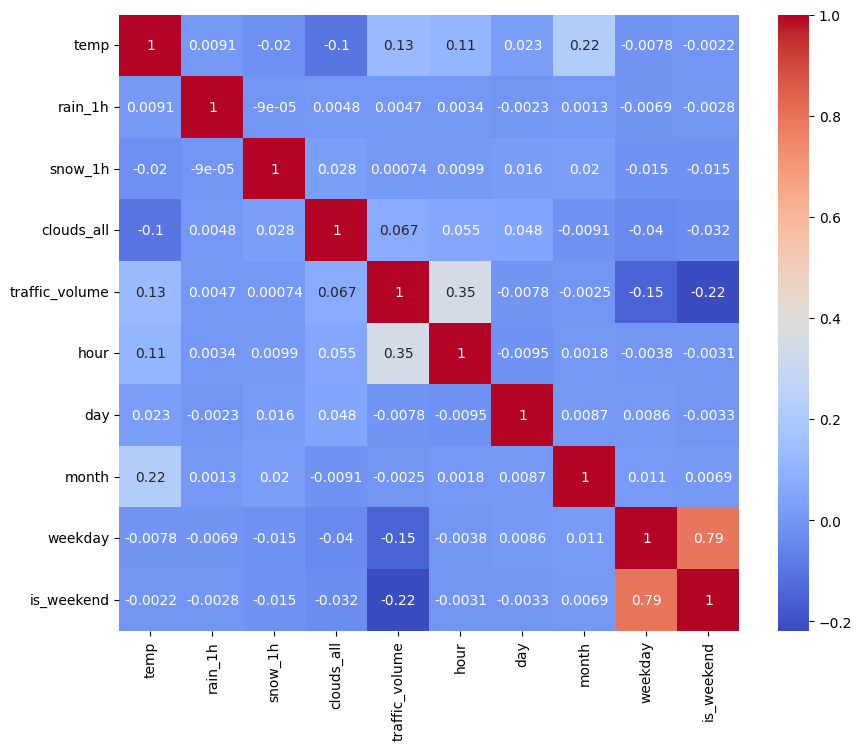

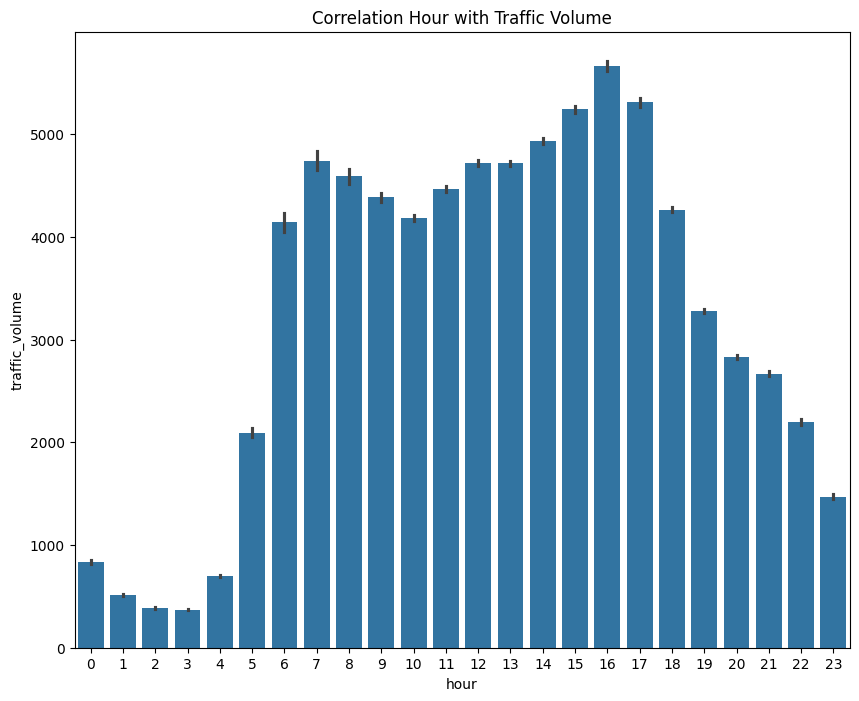

In [48]:
# Feature Importance
from sklearn.inspection import permutation_importance

result = permutation_importance(
    main_pipeline,
    x_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='neg_mean_absolute_error'
)

importance = pd.DataFrame({
    'feature': x_test.columns,
    'importance': result.importances_mean
}).sort_values('importance', ascending=False)

print(importance)

# Correrlation with new feature
df_num = df.select_dtypes(include='number')
plt.figure(figsize=(10,8))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.show()

# Correlation hour and target
plt.figure(figsize=(10,8))
sns.barplot(data=df, x='hour', y='traffic_volume')
plt.title('Correlation Hour with Traffic Volume')
plt.show()